## Prepare pickles

In [2]:
import pandas as pd

pd.read_csv('../stats-all-latest.csv').to_pickle('../stats-all-latest.pkl')
# pd.read_csv('stats-aws-latest.csv').to_pickle('stats-aws-latest.pkl')
# pd.read_csv('stats-gcp-latest.csv').to_pickle('stats-gcp-latest.pkl')

1


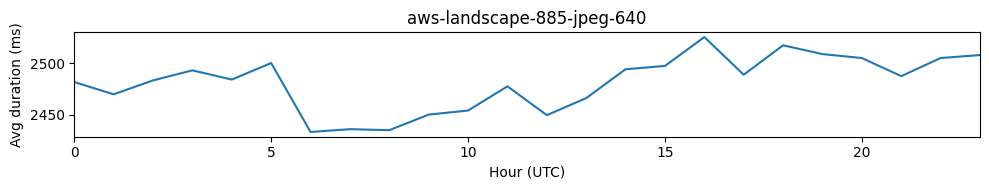

2


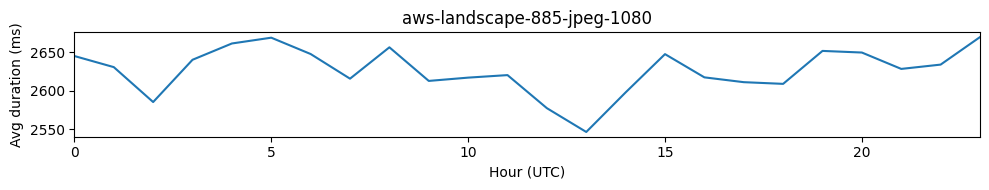

3


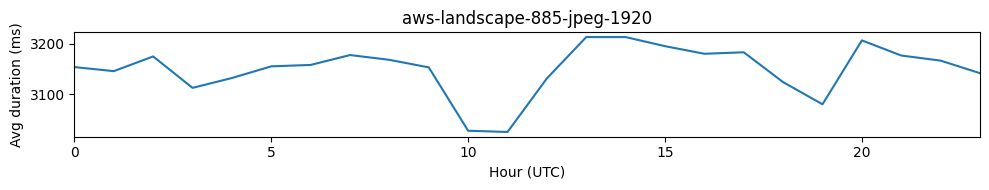

4


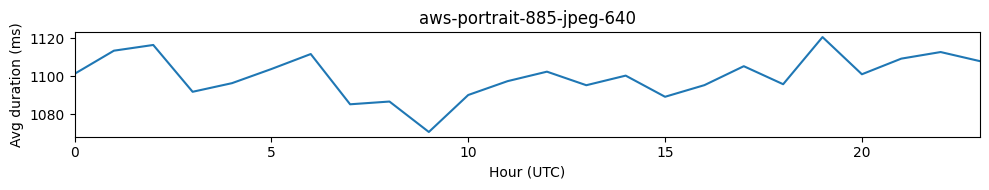

5


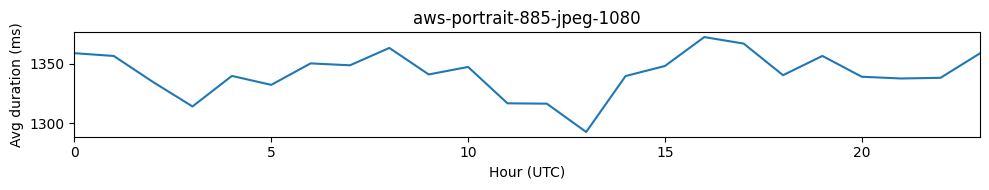

6


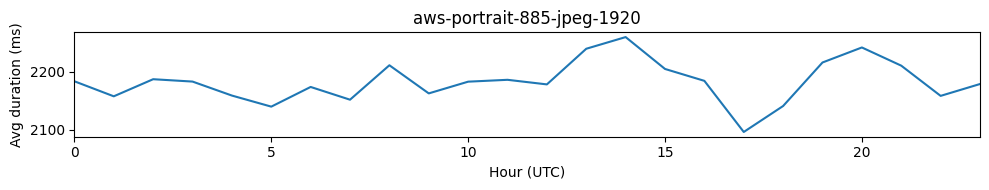

7


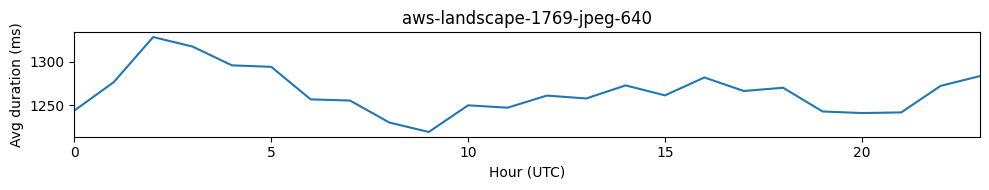

8


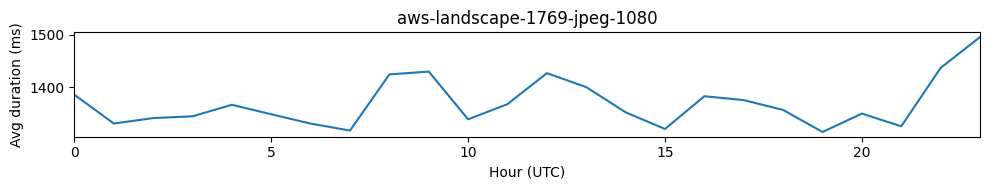

9


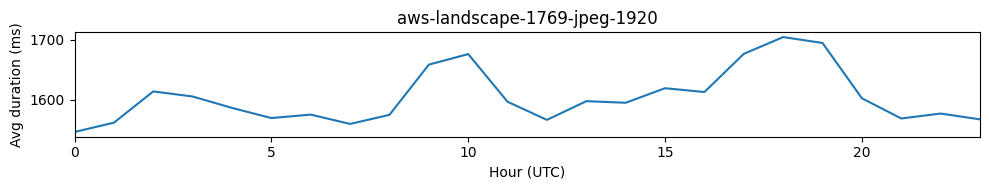

10


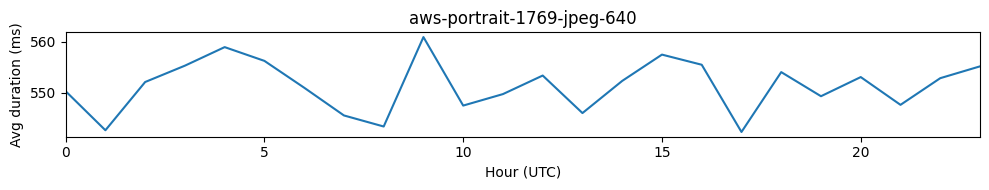

11


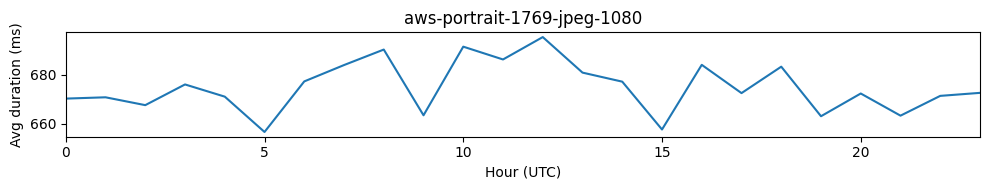

12


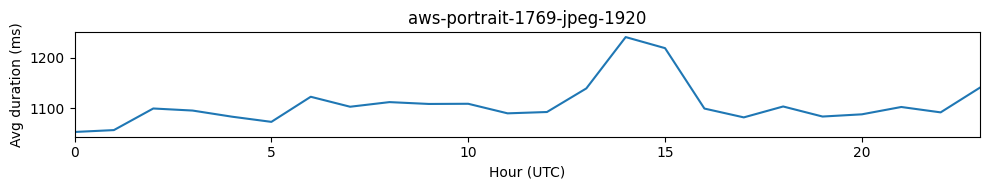

13


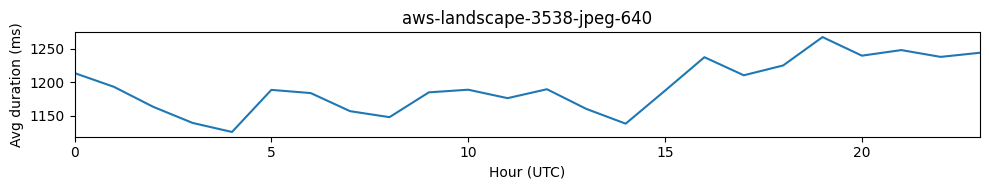

14


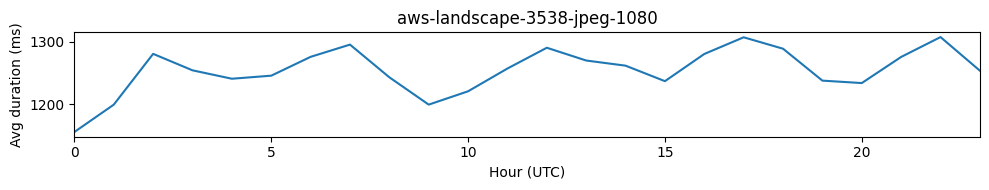

15


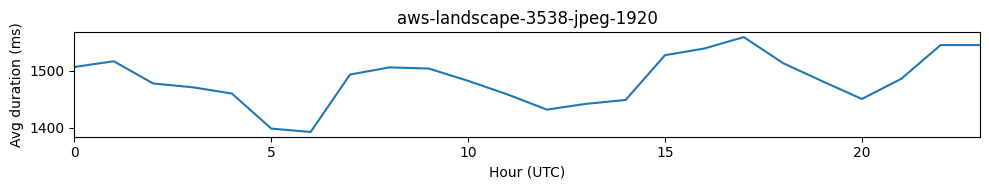

16


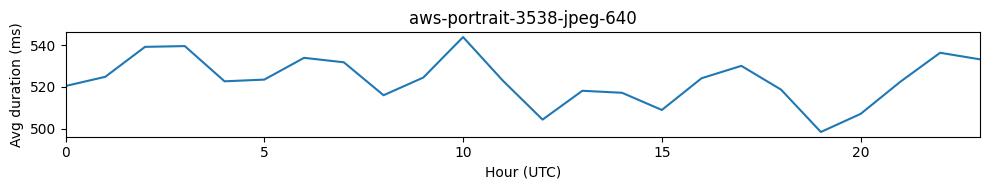

17


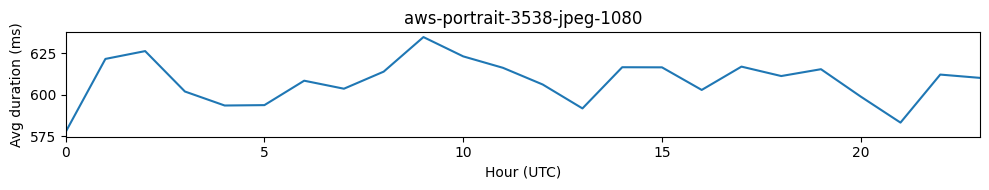

18


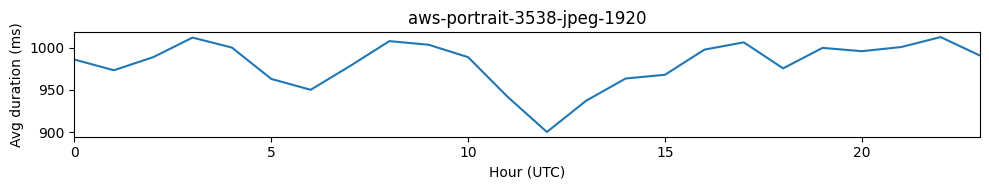

19


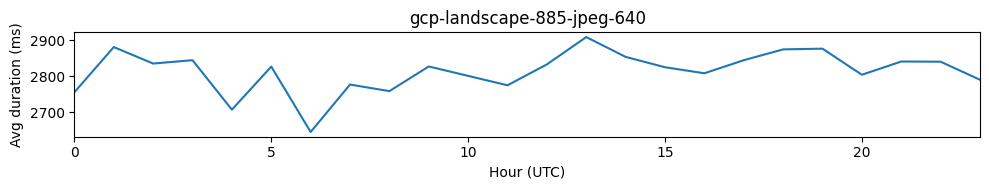

20


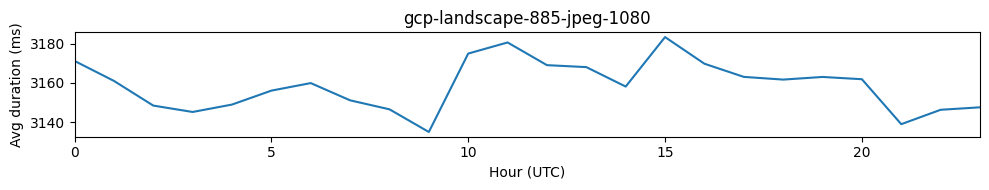

21


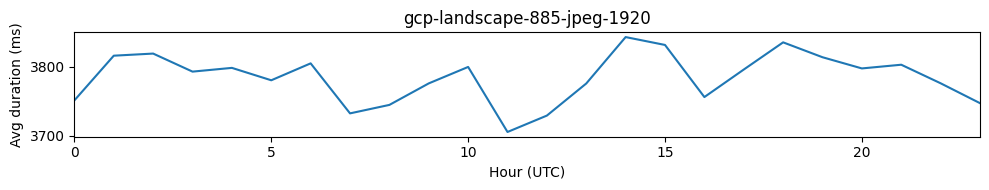

22


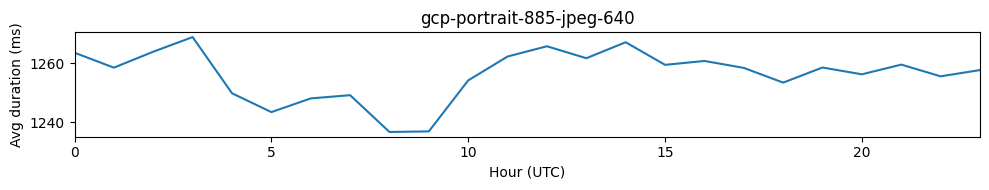

23


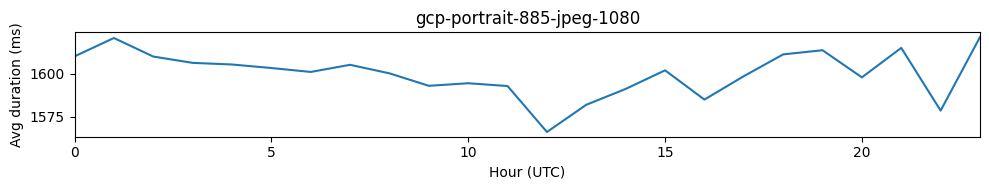

24


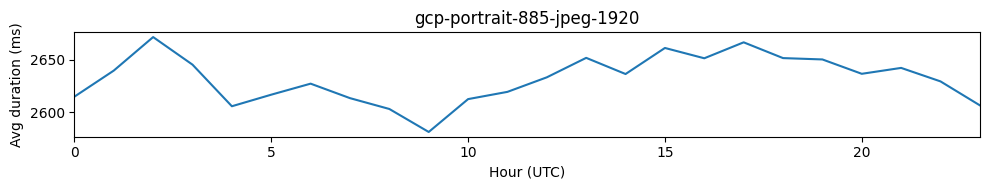

25


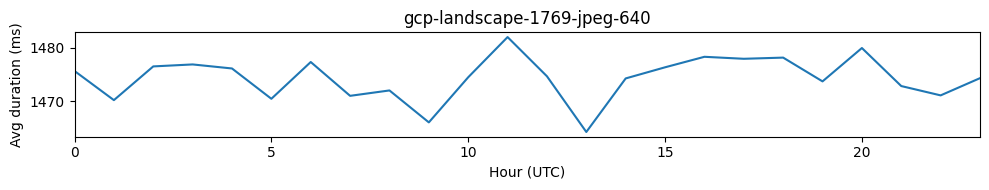

26


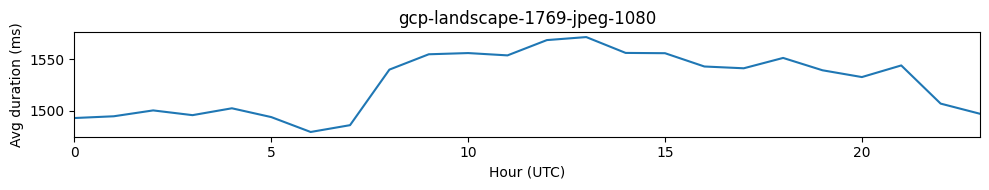

27


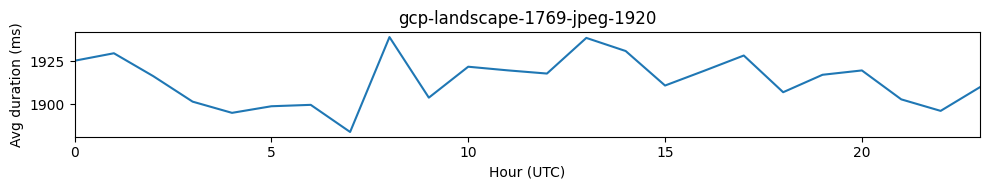

28


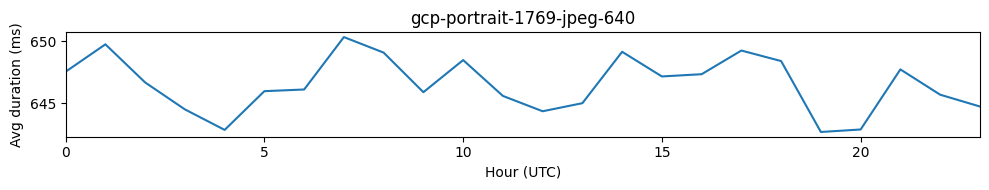

29


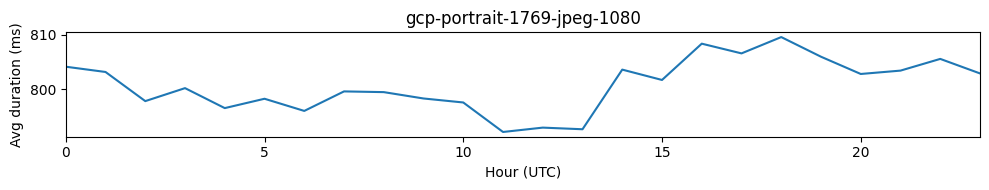

30


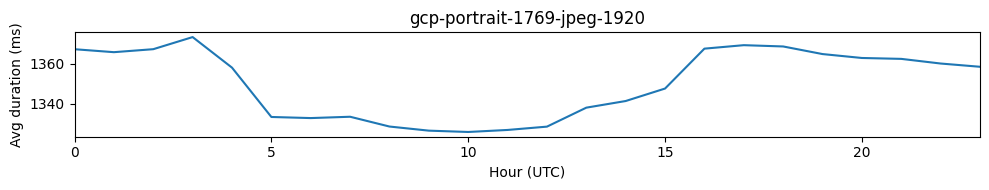

31


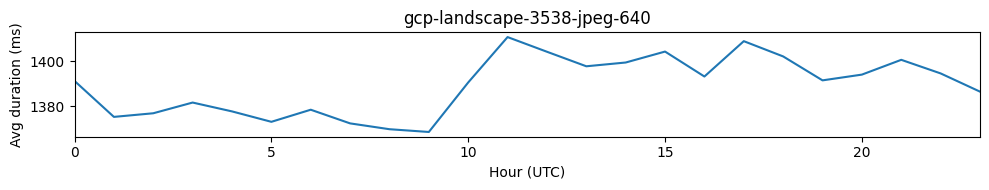

32


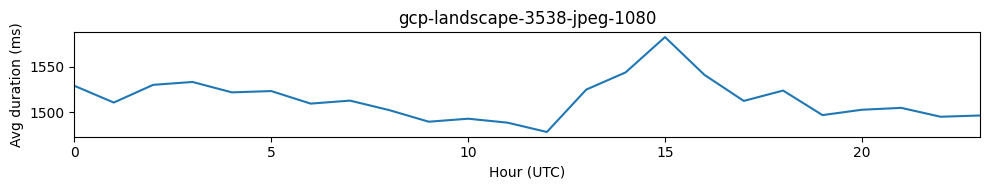

33


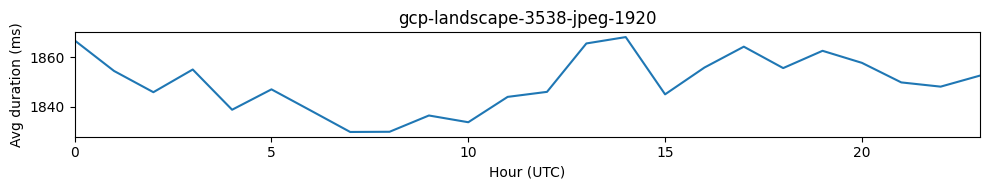

34


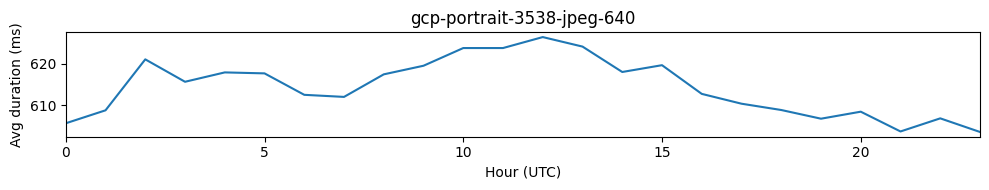

35


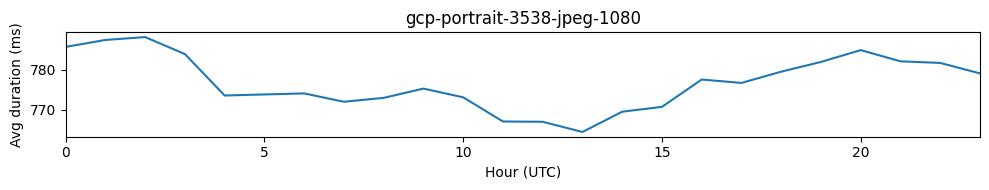

36


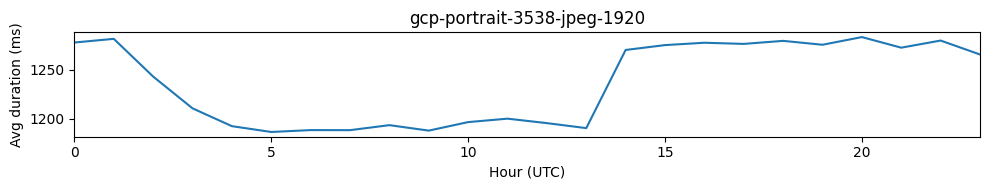

In [ ]:
# create a chart that will render values in the dataframe
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


df = pd.read_pickle('../stats-all-latest.pkl')

# Convert the 'isoDate' column to datetime objects
df['isoDate'] = pd.to_datetime(df['!isoDate'])
df = df.set_index("isoDate").sort_index()


# Extract the hour from the 'isoDate'
df["dow"] = df.index.day_of_week
df["hod"] = df.index.hour
df["how"] = (df["dow"] * 24) + df["hod"]

# Filter data for particular output format
# df = df[df['outputFormat'] == 'jpeg']

# Group by the specified columns and calculate the trimmed mean of 'durationImageProcessingMs'
def trimmed_mean(x):
    return stats.trim_mean(x, 0.01)  # Trim 1% from both tails

# Group by the specified columns and calculate the mean 'durationImageProcessingMs'
# grouped_df = df.groupby(['imageName', 'outputWidth', 'providerMemoryAssociated', 'how'])['durationImageProcessingMs'].agg(trimmed_mean).reset_index()
grouped_df = df.groupby(['imageName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated', 'providerName', 'hod'])['durationProcessingMs'].mean().reset_index()

index=1
# Plotting the results
for name, group in grouped_df.groupby(['providerName', 'providerMemoryAssociated', 'imageName', 'outputWidth', 'outputFormat', ]):
    print(f"{index}")
    index+=1
    fig, ax = plt.subplots(figsize=(10, 2))
    lbl_provider, lbl_memory, lbl_image, lbl_width, lbl_format = name
    # ax.plot(group['hod'], group['durationProcessingMs'], label=str(name))
    ax.plot(group['hod'], group['durationProcessingMs'])
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Avg duration (ms)")
    ax.set_title(f"{lbl_provider}-{lbl_image}-{lbl_memory}-{lbl_format}-{lbl_width}")
    ax.set_xlim(0, 23)
    plt.tight_layout()
    plt.show()